In [2]:
!pip install mysql-connector-python


     |████████████████████████████████| 390 kB 4.0 MB/s eta 0:00:01
     |████████████████████████████████| 981 kB 35.0 MB/s eta 0:00:01


In [13]:
!pip install seaborn

     |████████████████████████████████| 293 kB 4.7 MB/s eta 0:00:01


In [14]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:

# Connect to the database
conn = mysql.connector.connect(
    host="127.0.0.1",       
    port=3306,
    user="root",
    password="thudo1996",  ### your password
    database="movieRecSys"
)


#### Rating Distribution Analyst
We analysed how users rate movies. The distribution is skewed toward higher ratings.
- Over **85%** of ratings fall between **3 and 5**, suggesting that users tend to rate positively.
- The most frequent rating is **4 stars**, followed by 3 and 5. 
- This indicates a **positive rating bias** - users mostly rating movies they already liked

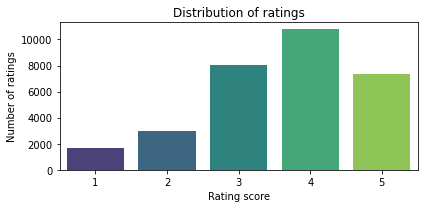

In [53]:
query1 = """
SELECT r.rating, COUNT(*) AS num_ratings
FROM ratings r
GROUP BY r.rating
ORDER BY num_ratings DESC;
"""
df_1 = pd.read_sql(query1, conn)

### plot
plt.figure(figsize=(6, 3))
sns.barplot(x='rating', y='num_ratings', data=df_1, palette='viridis')
plt.title('Distribution of ratings')
plt.xlabel('Rating score')
plt.ylabel('Number of ratings')
plt.tight_layout()
plt.show()

#### Analyzing Popularity Bias in Movie Ratings

In this analysis, we investigate **popularity bias** in the MovieLens dataset by visualizing the relationship between the **average rating** and the **number of user interactions (ratings)** each movie receives.

Our findings reveal a **highly skewed interaction distribution**: a small subset of movies—classified as popular—attract the vast majority of user ratings. These are likely well-known or widely promoted titles. In contrast, the vast majority of movies in the catalog receive minimal user engagement, indicating a long-tail distribution. These unpopular or underexposed movies often go unnoticed despite some of them achieving very high average ratings, suggesting the presence of hidden gems

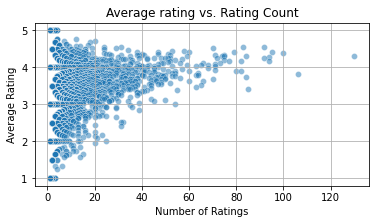

In [52]:
query2 = """
SELECT m.name, ROUND(AVG(r.rating), 2) AS avg_rate, COUNT(r.rating) as num_rate
FROM movies m
JOIN ratings r on m.movie_id = r.movie_id
GROUP BY m.name
ORDER BY avg_rate DESC;
"""
df_2 = pd.read_sql(query2, conn)

plt.figure(figsize=(6, 3))
sns.scatterplot(x='num_rate', y='avg_rate', data=df_2, alpha=0.5)
plt.title('Average rating vs. Rating Count')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()


**CONCLUSION AND BUSINESS VALUES**:
In this analysis, we identified a strong **popularity bias** in user ratings: a small number of movies received the majority of user interactions, while most movies remained largely unrated despite some having high average ratings. This skew is driven by a **positive feedback loop**, where users tend to engage with well-known or widely promoted titles they already expect to enjoy.
This behavior distorts both user feedback and recommendation accuracy, as interaction frequency alone fails to reflect true content quality. 

To address this, we recommend two strategies:
- Marketing teams should intentionally surface and promote diverse or underexposed movies to encourage broader engagement and ratings.

- Recommendation systems should incorporate diversity-aware algorithms—such as long-tail boosting to ensure high-quality niche content is not systematically excluded.

These approaches can reduce bias, improve coverage and fairness, and unlock hidden user interest, ultimately enhancing personalization and driving long-tail content revenue.